Shape of Dataset:
(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null 

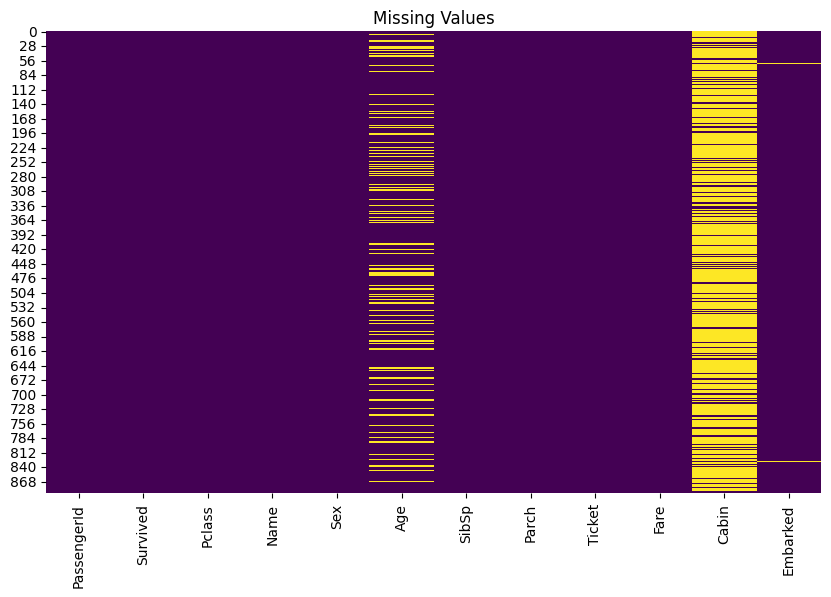

Duplicate Rows: 0
After Removing: (891, 11)


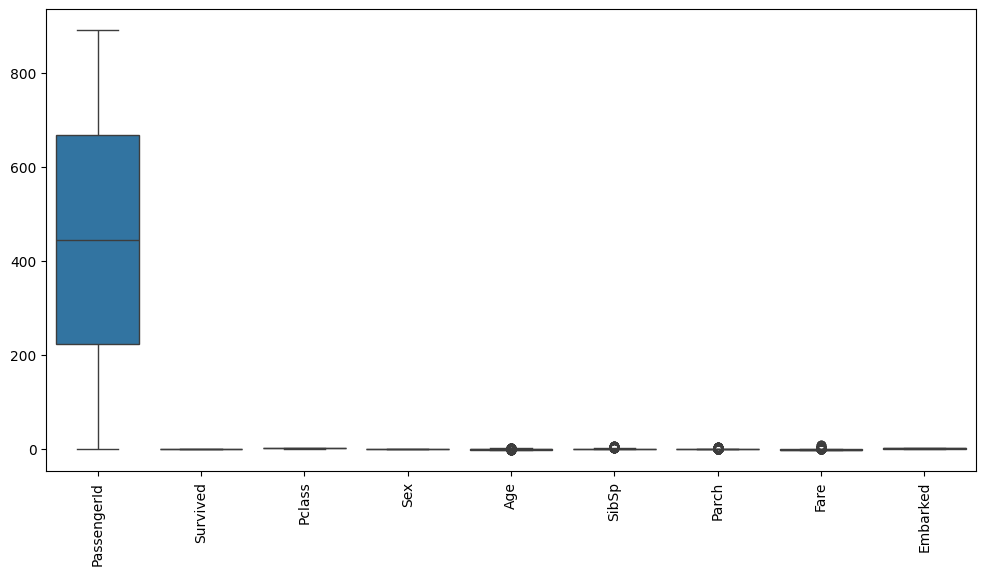

(577, 9)
Dataset Saved Successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("Shape of Dataset:")
print(df.shape)
print(df.dtypes)
df.info()
df.describe()
df.isnull().sum()
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)

plt.title("Missing Values")
plt.show()
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)
df.isnull().sum()
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removing:", df.shape)
df.select_dtypes(include="object").columns
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])
df.drop(["Name","Ticket"], axis=1, inplace=True)
df.head()
scaler = StandardScaler()

columns = ["Age","Fare"]

df[columns] = scaler.fit_transform(df[columns])

df.head()
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()
Q1 = df.quantile(0.25)

Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~(
        ((df < (Q1 - 1.5 * IQR)) |
         (df > (Q3 + 1.5 * IQR)))
    ).any(axis=1)
]

print(df.shape)
df.head()

df.describe()
df.to_csv("Cleaned_Titanic_Dataset.csv", index=False)

print("Dataset Saved Successfully")
from google.colab import files

files.download("Cleaned_Titanic_Dataset.csv")